In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import math

dim x is: (100, 2)
dim y is: (100, 1)


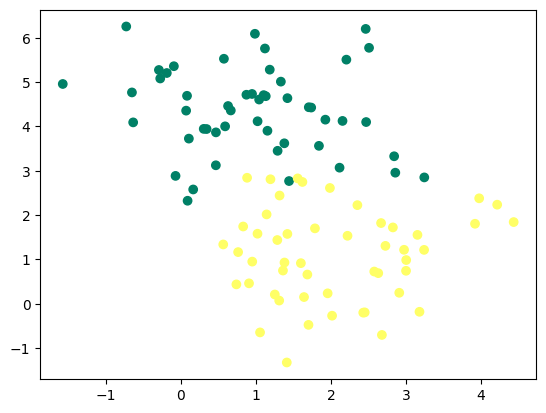

In [2]:
X,y=make_blobs(n_samples=100,n_features=2,random_state=0,centers=2)
y=y.reshape((y.shape[0],1))
print('dim x is:',X.shape)
print('dim y is:',y.shape)
plt.scatter(X[:,0],X[:,1],c=y,cmap="summer")
plt.show()

In [3]:
#fonction d'initialisation
def initialisation(X):
    W=np.random.randn(X.shape[1],1)
    b=np.random.randn(1)
    return (W,b)

W,b=initialisation(X)
b

array([-2.57368789])

In [4]:
# le model 
def model(X,W,b):
    Z=X.dot(W)+b
    A=1/(1+np.exp(-Z))
    return A



In [5]:
# fonction de cout log loss
def log_loss(A,y):
    eps=1e-15
    L=(1/len(y))*np.sum(-y*np.log(A+eps)-(1-y)*np.log(1-A+eps))
    return L


In [6]:
 #gradient 
def gradient (A,X,y):
    dW=(1/len(y))*np.dot(X.T,A-y)
    db=(1/len(y))*np.sum(A-y)
    return (dW,db)


In [7]:
#update 
def update(dW,db,W,b,learning_rate):
    W=W-learning_rate*dW
    b=b-learning_rate*db
    return(W,b)

In [8]:
from sklearn.metrics import accuracy_score
def predict(X, W, b):
    A = model(X, W, b)
    # print(A)
    return A >= 0.5

In [9]:
from tqdm import tqdm

In [10]:
#the main artificial neuron
def artificial_neuron(X,y,learning_rate=0.1,n_iter=100):
    #initialiser W,b
    W,b=initialisation(X)
    Loss=[]
    acc=[]
    for i in tqdm(range (n_iter)):
        A=model(X,W,b)
        Loss.append(log_loss(A,y))
        y_pred=predict(X,W,b)
        acc.append(accuracy_score(y,y_pred))
        dW,db=gradient(A,X,y)
        W,b=update(dW,db,W,b,learning_rate)

   
#plot loss function during the training
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(Loss)
    plt.subplot(1,2,2)
    plt.plot(acc)
    plt.show()
    return (W,b)

100%|██████████| 100/100 [00:00<00:00, 3886.39it/s]


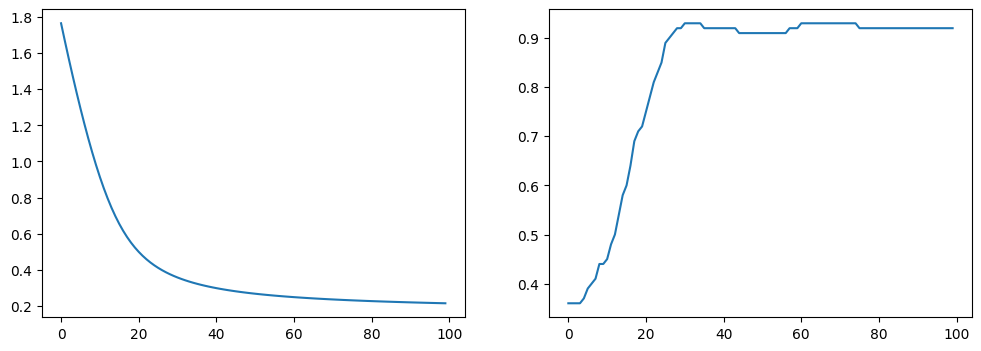

(array([[ 0.85860721],
        [-1.07206524]]),
 array([1.23167836]))

In [11]:
#showing the plot 
artificial_neuron(X,y,learning_rate=0.1,n_iter=100)

In [12]:
# prediction 
def predict(X,W,b):
    A=model(X,W,b)
    return A>=0.5
y_pred= predict(X,W,b)
print(y_pred)
# accuracy of the mdel
print("the accuracy is :",accuracy_score(y,y_pred))
print("the W is : ",W,"the b is : ",b)

[[False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]]
the accuracy is : 0.5
the W is :  [[-1.28282816]
 [-2.46163549]] the b is :  [-2.57368789]


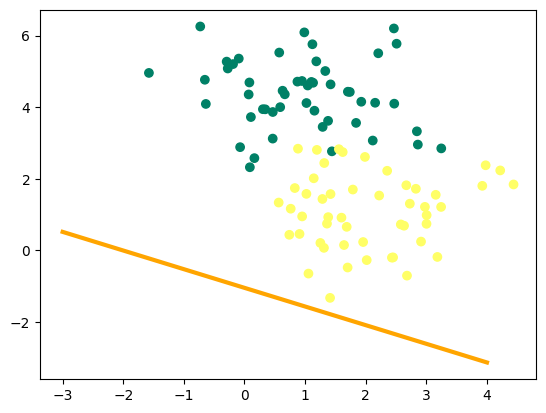

In [13]:
plt.scatter(X[:,0],X[:,1],c=y,cmap="summer")
#we scaatter the line which separate the data into two we do the splitting
x0 = np.linspace(-3,4,100)
x1=(-W[0]*x0-b)/W[1]
plt.plot(x0,x1,c='orange',lw=3)
plt.show()

In [14]:
#the weigths that gives us 93%% accuracy 
#the W is : w1 [[ 0.13253675] w2 [-0.31836148]] 
#the b is :  [0.46881382]

In [15]:
import h5py
import numpy as np
from utilities import *


In [16]:
X_train, y_train, X_test, y_test = load_data()

In [17]:
print(X_train.shape)
print(y_train.shape)
print(np.unique(y_train, return_counts=True))

(1000, 64, 64)
(1000, 1)
(array([0., 1.]), array([500, 500]))


In [18]:
print(X_test.shape)
print(y_test.shape)
print(np.unique(y_test, return_counts=True))

(200, 64, 64)
(200, 1)
(array([0., 1.]), array([100, 100]))


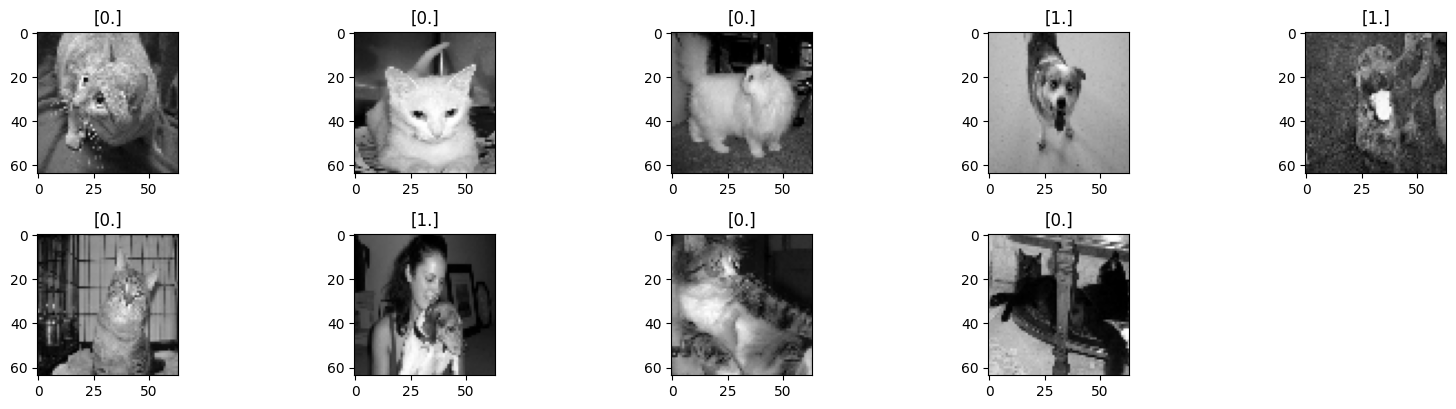

In [19]:

plt.figure(figsize=(16, 8))
for i in range(1, 10):
    plt.subplot(4, 5, i)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.tight_layout()
plt.show()

In [20]:
x_train_reshape=X_train.reshape(X_train.shape[0],X_train.shape[1]*X_train.shape[2])/X_train.max() #X_train.shape[1]*X_train.shape[2] on peut la changer par -1
x_train_reshape.shape

(1000, 4096)

In [21]:
#maintenant pour test set and normalization
x_test_reshape=X_test.reshape(X_test.shape[0],X_test.shape[1]*X_test.shape[2])/X_test.max()
x_train_reshape.shape

(1000, 4096)

100%|██████████| 1000/1000 [00:07<00:00, 137.62it/s]


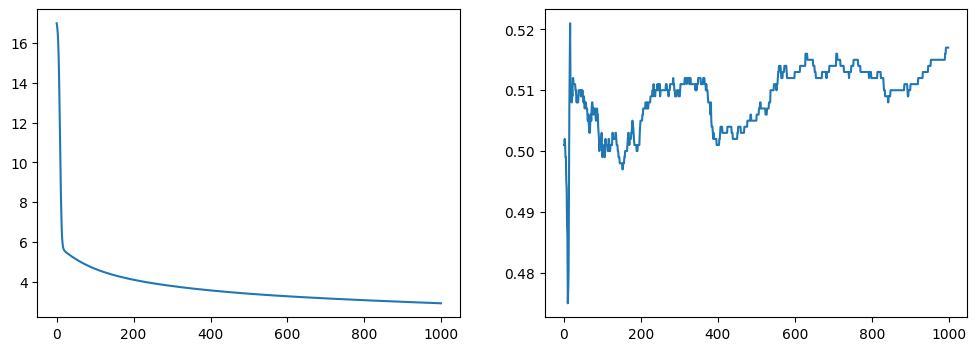

In [22]:

W, b = artificial_neuron(x_train_reshape, y_train,learning_rate=0.01,n_iter=1000)